<a href="https://colab.research.google.com/github/jgreen83/Spring2026-Connectome-Pseudospectra/blob/main/Sampling_plus_pseudospectra.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Connectomes from degrees

In [33]:
from scipy.optimize import minimize
from scipy import stats
from scipy import linalg
from scipy.linalg import qr
from scipy.linalg import eigvals
from scipy.linalg import expm
from scipy.integrate import simpson
import numpy as np
import functools
import networkx as nx
import tqdm
import collections
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from pseudopy import NonnormalAuto, demo
from pseudopy import NonnormalMeshgrid, NonnormalMeshgridAuto, NonnormalTriang, NonnormalPoints
from pseudopy import nonnormal

import graph_tool.all as gt

## Negative binomial

In [2]:
def calc_var_mean(data):
    return np.var(data, ddof=1), np.mean(data)

def fit_neg_binomial(data):
    def _neg_log_likelihood(params):
        r, p = params
        if r <= 0 or not (0 < p < 1):
            return np.inf
        return -np.sum(stats.nbinom.logpmf(data, r, p))

    # Sample mean and variance
    var, mean = calc_var_mean(data)

    p0 = mean / var
    r0 = mean**2 / (var - mean)

    p0 = np.clip(p0, 1e-5, 1 - 1e-5) ## what does this do
    r0 = max(r0, 1e-5)


    # Run optimization problem (like in 563)
    result = minimize(_neg_log_likelihood, [r0, p0], bounds=[(1e-5, None), (1e-5, 1 - 1e-5)])
    r_fit, p_fit = result.x

    # Formulas for mean and variance in terms of r_fit and p_fit (see from negative binomia dist uses)
    fitted_mean = r_fit * (1 - p_fit) / p_fit
    fitted_var = r_fit * (1-p_fit) / p_fit**2
    fitted_var_over_mean = fitted_var / fitted_mean

    print(f"Fitted Negative Binomial Parameters: r = {r_fit:.3f}, p = {p_fit:.3f}")
    print(f"Fitted mean: {fitted_mean:.3f}")
    print(f"Fitted var: {fitted_var:.3f}")
    print(f"Fitted var/mean: {fitted_var_over_mean:.3f}")

    return r_fit, p_fit

def r_from_p(p, m):
    return p / (1-p) * m

def var_from_r_p(r, p):
    return r * (1-p) / p**2

def mean_from_r_p(r, p):
    return r * (1 - p) / p

def sample_from_neg_binomial(r, p, n_samples, eps=1e-6):
    samples = stats.nbinom.rvs(r, p, size=n_samples)
    if eps is not None:
        target_sum = r * (1 - p) / p * n_samples # Want to make the mean of sampled set the same as the theoretical mean
        while abs(1-np.sum(samples) / target_sum) > eps:
            samples = stats.nbinom.rvs(r, p, size=n_samples)
    return samples

def sample_from_neg_binomial_var_mean(v, m, n_samples, eps=1e-6):
    p = 1. / (v / m)
    r = r_from_p(p, m)

    return sample_from_neg_binomial(r, p, n_samples, eps=eps)

## Schur

In [3]:
def feedforward_ratio(g, complex_decomp=True):
    """ Computes the Schur decomposition and ff-ratio of a square matrix A

    Parameters:
        g: nx graph
        complex_decomp: if True, use complex Schur; else real Schur

    Returns:
        ff_ratio: fraction of Frobenius norm above the diagonal in T
        T: the Schur form of A (upper triangular)
        Q: the unitary/orthogonal basis matrix
    """
    A = nx.to_numpy_array(g, dtype=float)

    if not np.all(np.isfinite(A)):
        return np.nan, np.zeros_like(A), np.zeros_like(A)

    if A.shape[0] != A.shape[1]:
        return np.nan, np.zeros_like(A), np.zeros_like(A)

    if A.shape[0] == 1:
        return 0, np.array([[0]]), np.array([[1]])

    try:
        T, Q = linalg.schur(A, output="complex" if complex_decomp else "real")
    except np.linalg.LinAlgError:
        return np.nan, np.zeros_like(A), np.zeros_like(A)

    total_norm_sq = np.linalg.norm(T, "fro") ** 2

    upper_tri_mask = np.triu(np.ones_like(T), k=1) # Multiplying upper tri matrix with a lower tri matrix gives product of diagonal entries
    upper_norm_sq = np.sum(np.abs(T * upper_tri_mask) ** 2)

    ff_ratio = upper_norm_sq / total_norm_sq if total_norm_sq > 0 else 0

    return ff_ratio, T, Q

# Look this up, make sure it is correct!
def henrici_departure(g_nx):
    """Henrici’s departure from normality

    Parameters:
        g: nx graph

    Returns:
        henricis score
    """
    A = nx.to_numpy_array(g_nx, dtype=float)
    fro_norm_sq = np.linalg.norm(A, ord="fro") ** 2
    eig_norm_sq = np.sum(np.abs(linalg.eigvals(A)) ** 2)
    return np.sqrt(fro_norm_sq - eig_norm_sq.real) / np.linalg.norm(A, ord="fro")

## Parameter sets

In [4]:
# Fit parameters for a circuit of L4 neurons
# Dictionary of dictionaries
param_sets = {
    "L4_wot": {
        "n_neurons": 306,
        "n_connections": 3915,
        "var_in_fit": 62.45,
        "var_out_fit": 53.34,
    },
    "L4_wt": {
        "n_neurons": 306,
        "n_connections": 1566,
        "var_in_fit": 12.576,
        "var_out_fit": 15.927,
    }
}

for k in param_sets:
    param_sets[k]["mean"] = param_sets[k]["n_connections"] / param_sets[k]["n_neurons"]

In [5]:
param_sets

{'L4_wot': {'n_neurons': 306,
  'n_connections': 3915,
  'var_in_fit': 62.45,
  'var_out_fit': 53.34,
  'mean': 12.794117647058824},
 'L4_wt': {'n_neurons': 306,
  'n_connections': 1566,
  'var_in_fit': 12.576,
  'var_out_fit': 15.927,
  'mean': 5.117647058823529}}

## Sampling connectomes - example

In [6]:
param_set = param_sets["L4_wt"]

In [7]:
def degree_sampler(idx, in_, out_):
    return (in_[idx], out_[idx])

# Sample degrees
sampled_in_degrees = sample_from_neg_binomial_var_mean(param_set["var_in_fit"], param_set["mean"], param_set["n_neurons"])
sampled_out_degrees = sample_from_neg_binomial_var_mean(param_set["var_out_fit"], param_set["mean"], param_set["n_neurons"])

# Sample graph (once we have the degrees that we will use for the sample graph we need to construct it)
degree_sampler_instantiated = functools.partial(degree_sampler, in_=sampled_in_degrees, out_=sampled_out_degrees)
g_gt = gt.random_graph(param_set["n_neurons"], degree_sampler_instantiated, verbose=False)
sampled_edges = np.array([[int(e.source()), int(e.target())] for e in g_gt.edges()])

# Scoring
g_nx = nx.DiGraph()
g_nx.add_edges_from(sampled_edges)
ff_ratio = feedforward_ratio(g_nx)[0]
henricis = henrici_departure(g_nx)

ff_ratio, henricis

(np.float64(0.6480321837553092), np.float64(0.8050044619474532))

## Sampling connectomes - across variances

$var_{in} = var_{out}$

In [8]:
param_set = param_sets["L4_wt"]

In [9]:
var_over_means = np.linspace(1, 4, 20)
var_over_means[var_over_means == 1] += 1e-4 # var_over_mean has to be > 1 ### Why?

data_coll = collections.defaultdict(list)

# For each variance value, create 10 graphs and add the resulting statistics to the dictionary
for var_over_mean in tqdm.tqdm(var_over_means):
    for _ in range(10):
        # Sample degrees
        sampled_in_degrees = sample_from_neg_binomial_var_mean(var_over_mean * param_set["mean"], param_set["mean"], param_set["n_neurons"])
        sampled_out_degrees = sample_from_neg_binomial_var_mean(var_over_mean * param_set["mean"], param_set["mean"], param_set["n_neurons"])

        # Sample graph
        degree_sampler_instantiated = functools.partial(degree_sampler, in_=sampled_in_degrees, out_=sampled_out_degrees)
        g_gt = gt.random_graph(param_set["n_neurons"], degree_sampler_instantiated, verbose=False)
        sampled_edges = np.array([[int(e.source()), int(e.target())] for e in g_gt.edges()])

        # Scoring
        g_nx = nx.DiGraph()
        g_nx.add_edges_from(sampled_edges)
        ff_ratio = feedforward_ratio(g_nx)[0]
        henricis = henrici_departure(g_nx)

        data_coll["var_over_mean"].append(var_over_mean)
        data_coll["ff_ratio"].append(ff_ratio)
        data_coll["henricis"].append(henricis)


sample_df = pd.DataFrame(data_coll)

100%|██████████| 20/20 [00:31<00:00,  1.57s/it]


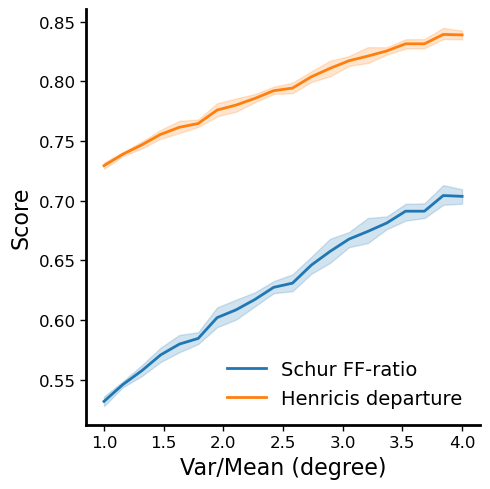

In [10]:
# Plotting FF_ratio and henricis vs variance/mean

fig, ax = plt.subplots(figsize=(5, 5))

sns.lineplot(data=sample_df, x="var_over_mean", y="ff_ratio", label="Schur FF-ratio", lw=2)
sns.lineplot(data=sample_df, x="var_over_mean", y="henricis", label="Henricis departure", lw=2)
ax.legend(frameon=False, fontsize=14)

ax.set_xlabel("Var/Mean (degree)", fontsize=16)
ax.set_ylabel("Score", fontsize=16)

# what do some of these settings do
ax.tick_params(axis='both', which='major', labelsize=12, width=1, length=4)

# what do these do
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.spines['bottom'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)


plt.tight_layout()
plt.show()

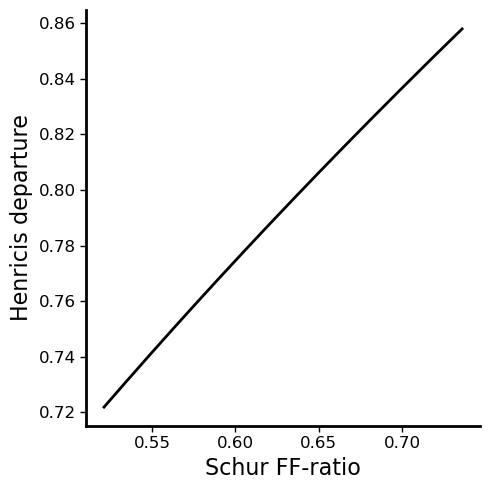

In [11]:
# Plot ff_ratio vs henricis
fig, ax = plt.subplots(figsize=(5, 5))

sns.lineplot(data=sample_df, x="ff_ratio", y="henricis", c="k", lw=2)

ax.set_xlabel("Schur FF-ratio", fontsize=16)
ax.set_ylabel("Henricis departure", fontsize=16)

ax.tick_params(axis='both', which='major', labelsize=12, width=1, length=4)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.spines['bottom'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)


plt.tight_layout()
plt.show()

# Pseudospectra

In [12]:
# def upper_bd_norm(W, t_max=10, delta_t=1000):
#     """ Compute the upper bound on the matrix norm"""
#     ##### NEED TO COMPLETE######
#     A = W - np.eye(len(W))
#     M = 0
#     t = np.linspace(0, t_max, delta_t)
#     mat_norm = []
#     for i in range(0, delta_t):
#         mat_norm.append(np.linalg.norm(linalg.expm(A*t[i])))
#         if mat_norm[i] > M:
#             M = mat_norm[i]

#     plt.plot(t, mat_norm,)
#     return M

def upper_bd_norm(W, t_max=10, delta_t=1000):
    """ Compute the upper bound on the matrix norm of e^{(W-I)t} (vectorized) """

    A = W - np.eye(len(W))

    # Time points
    t_vals = np.linspace(0, t_max, delta_t)

    # Compute norms using list comprehension (avoids explicit Python loop for plotting)
    mat_norm = np.array([np.linalg.norm(linalg.expm(A * t)) for t in t_vals])

    M = np.max(mat_norm)

    # Plot
    plt.figure(figsize=(6,4))
    plt.plot(t_vals, mat_norm)
    plt.xlabel("t")
    plt.ylabel("||exp((W-I)t)||")
    plt.title("Matrix norm over time")
    plt.grid(True)
    plt.show()

    return M

def eps_unity(W):
    """ Returns the epsilon contour of the pseudospectra that first crosses Re(lambda) = 1"""
    # pseudo = NonnormalAuto(W, 1e-5, 1)
    pseudo = NonnormalMeshgrid(W, real_min=-2, real_max=2, imag_min=-2, imag_max=2, real_n=100, imag_n=100, method='svd')

    # Epsilons arranged in increasing order
    epsilons = [10**k for k in range(-5, 0)]
    contours_list = []

    smallest_eps = np.inf

    for eps in epsilons:
        paths = pseudo.contour_paths(eps)
        contours_list.append(paths)  # append the list of paths for this epsilon

        if smallest_eps == np.inf: # only do this until first epsilon is found
            for path in paths:
                x_coords = path[:,0]
                if np.any(x_coords >= 1):
                    print(f"Epsilon {eps} contour crosses Re(lambda)=1")
                    smallest_eps = eps
                    break

    print(f"Number of epsilon levels: {len(contours_list)}")
    for i, paths in enumerate(contours_list):
        print(f"epsilon={epsilons[i]}, number of paths: {len(paths)}")

    if smallest_eps == np.inf:
        print("No epsilon contour crosses Re(lambda)=1 in tested range")
    return smallest_eps, contours_list

def scale_network_stable(W, epsilon=1e-2):
    """
    Scale the weight matrix W so that the real part of its largest eigenvalue
    is slightly below 1 for stability.

    Parameters
    ----------
    W : ndarray (N,N)
        Network connectivity matrix
    epsilon : float
        Small positive number to keep eigenvalues slightly below 1
    """
    eigvals = np.linalg.eigvals(W)
    lambda_max_real = np.max(eigvals.real)

    # Scale matrix
    scale_factor = (1 - epsilon) / lambda_max_real
    print("Scale factor:", scale_factor)
    W_scaled = W * scale_factor

    return W_scaled

def ts_lower_bd(g_nx):
    """ Compute the S3 timescale lower bound from Goldman Appendix"""
    W = nx.to_numpy_array(g_nx, dtype=float)
    W_scaled = scale_network_stable(W)
    M = upper_bd_norm(W)
    eps = eps_unity(W)
    return 1/(eps * M)


In [24]:
evals = np.linalg.eigvals(np.array([[1,2j],[3j,-1]]))
sorted_indices = np.argsort(evals)
sorted_evals = evals[sorted_indices]
sorted_evals[-1].imag

np.float64(2.23606797749979)

In [105]:
import numpy as np
from scipy.optimize import minimize_scalar

def complex_stability_radius(A):
    """
    Calculates the 2-norm complex stability radius of a matrix A.
    This is the same value as the smallest epsilon for which the eps-pseudospectrum intersects Re z = 0
    """
    n = A.shape[0]
    I = np.eye(n, dtype=complex)

    # Function to maximize: the 2-norm of the resolvent (which is the inverse of the smallest singular value)
    def resolvent_norm(omega):
        M = 1j * omega * I - A

        sigma_min = np.min(np.linalg.svd(M, compute_uv=False))
        return 1.0 / sigma_min

    res = minimize_scalar(lambda w: -resolvent_norm(w), bounds=(-1e3, 1e3), method='bounded')
    return 1.0 / (-res.fun)

In [106]:
def integral_comparison2D(A,c=0):
    tMax = 50
    ts = np.linspace(0,50,1000)
    eAs = [np.linalg.norm(expm(A*ts[i]),ord=2) for i in range(len(ts))]
    # eps = eps_zero(A)
    eps = complex_stability_radius(A)
    print('eps: ' + str(eps))
    M = max(eAs)
    t_star = (1-c)/(eps*M)

    ts = np.linspace(0,t_star,round(t_star/.01))
    eA_int = simpson([np.linalg.norm(expm(ts[i]*A),ord=2) for i in range(len(ts))],x=ts)
    
    thetas = np.linspace(0, np.pi, 100)

    eAv_ints = np.zeros_like(thetas)
    for i in range(len(thetas)):
        theta = thetas[i]
        v = np.array([[np.cos(theta)],[np.sin(theta)]])
        eAvs = [np.linalg.norm(expm(ts[j]*A).dot(v),ord=2) for j in range(len(ts))]
        eAv_ints[i] = simpson(eAvs,x=ts)/eA_int
    
    plt.plot(thetas,eAv_ints)

    return thetas,eAv_ints

eps: 0.24087299850949076


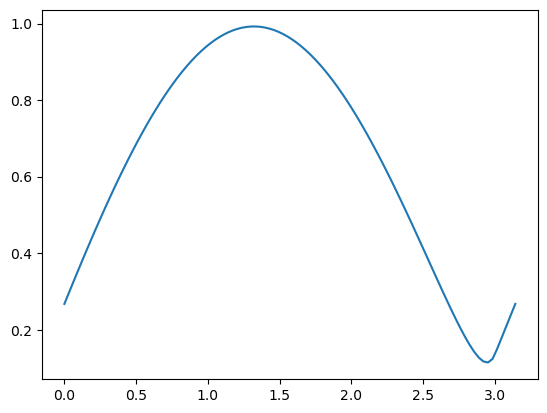

In [ ]:
A = np.array([[-1, 8],[ 0, -2]])

thetas,eAv_ints = integral_comparison2D(A)

In [ ]:
#expanding to multiple dimensions
def calc_eAint(A,c=0):
    """
    Calculates the point t_star at which pseudospectrum analysis guarantees \| e^{At} \|_2 \geq c, 
    then approximates the integral of the matrix exponential from time 0 until t_star. 

    Parameters: 
    A - matrix of which exponential is being considered. For our use case, commonly W - I.
    c - constant >= 0, adjustable to scale final integration time, as described above.

    Returns: 
    eAint - approximation via Simpson to int_0^{t_star}  \| e^{At} \|_2 dt
    """
    
    tMax = 50
    ts = np.linspace(0,50,1000)
    eAs = [np.linalg.norm(expm(A*ts[i]),ord=2) for i in range(len(ts))]
    eps = complex_stability_radius(A)
    print('eps: ' + str(eps))
    M = max(eAs)
    t_star = (1-c)/(eps*M)

    ts = np.linspace(0,t_star,round(t_star/.01))
    eAint = simpson([np.linalg.norm(expm(ts[i]*A),ord=2) for i in range(len(ts))],x=ts)

    return ts, eAint

def calc_eAvint(A,v,ts):
    #calculates int_0^{t_star}  \| e^{At} v \|_2 dt for a given vector v and a matrix A
    eAvs = [np.linalg.norm(expm(ts[j]*A).dot(v),ord=2) for j in range(len(ts))]
    return simpson(eAvs,x=ts)
    
def rand_v_ints(A,N):
    #N = number of random vectors v
    ts, eAint = calc_eAint(A)

    #N vectors of length matching A x 1
    eAv_ints = np.zeros(1,N)
    for i in range(len(N)):
        v = np.random.randn(len(A))
        v = v/np.linalg.norm(v,ord=2)
        eAv_ints[i] = calc_eAvint(A,v,ts)/eAint

    return eAv_ints

Scale factor: 0.18919920653853214


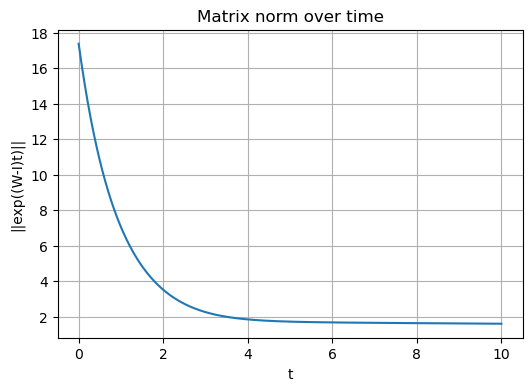

17.378147196982766


In [13]:
# Use g_nx (from above, sampled degrees from connectome)
W_sampled = nx.to_numpy_array(g_nx, dtype=float)

W_sampled_scaled = scale_network_stable(W_sampled)
print(upper_bd_norm(W_sampled_scaled))
# print(eps_unity(W_sampled_scaled)[0])

# Rescale matrix to have small eigenvalues
# W_scaled = scale_network_stable(W)
# print(np.max(eigvals(W_scaled)))

# print(upper_bd_norm(W_scaled))


# print(eps_unity(W_scaled)[0])

### Recreating Goldman Supplemental figures

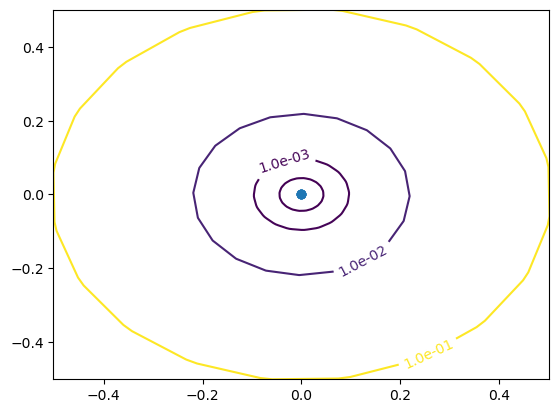

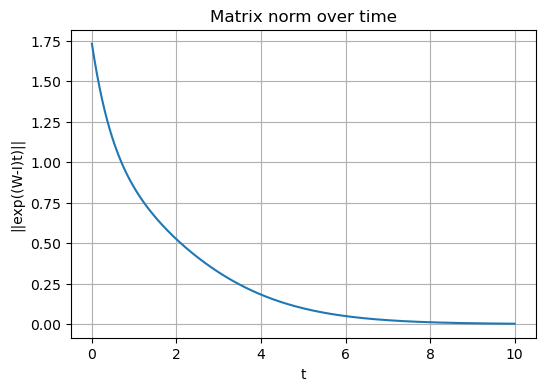

AttributeError: 'list' object has no attribute 'get_paths'

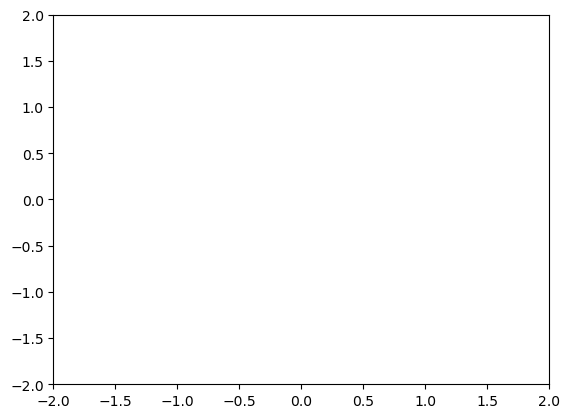

In [14]:
# Create Matrix
N = 3
np.random.seed(42)

# Generate orthogonal matrix U and define W, like before
def gram_schmidt(X):
    Q, _ = np.linalg.qr(X)
    return Q

random_vectors = np.random.randn(N, N)
U = gram_schmidt(random_vectors)

T = np.zeros((N, N))

# T is the FFW network, while W is the Funtionally FFW network
for i in range(1, N):
    T[i, i - 1] = 1.0

W = U @ T @ np.linalg.inv(U)

evals = eigvals(W)
plt.scatter(evals.real, evals.imag)

# compute pseudospectrum for the levels of interest between [1e-5, 1]
pseudo = NonnormalAuto(W, 1e-5, 1)

# plot
pseudo.plot([10**k for k in range(-4, 0)], spectrum=eigvals(W))
plt.show()

upper_bd_norm(W)
eps_unity(W)

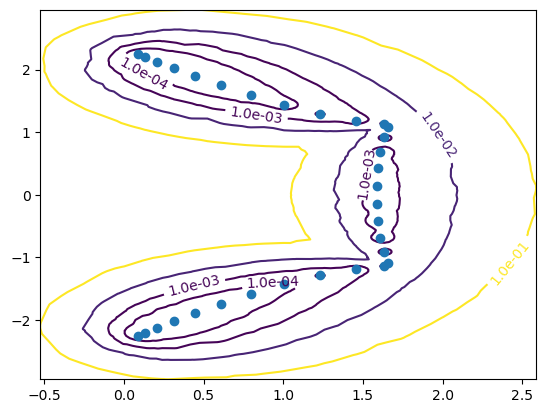

In [15]:
from pseudopy import NonnormalAuto, demo

# get Grcar matrix
A = demo.grcar(32).todense()

# compute pseudospectrum for the levels of interest between [1e-5, 1]
pseudo = NonnormalAuto(A, 1e-5, 1)

# plot
pseudo.plot([10**k for k in range(-4, 0)], spectrum=eigvals(A))
plt.show()

(100, 100)
(100, 100)
grid


/var/folders/nv/ptw4s9557gz0tr81x078vjt80000gq/T/ipykernel_46099/1277578872.py:109: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


grid
grid
grid


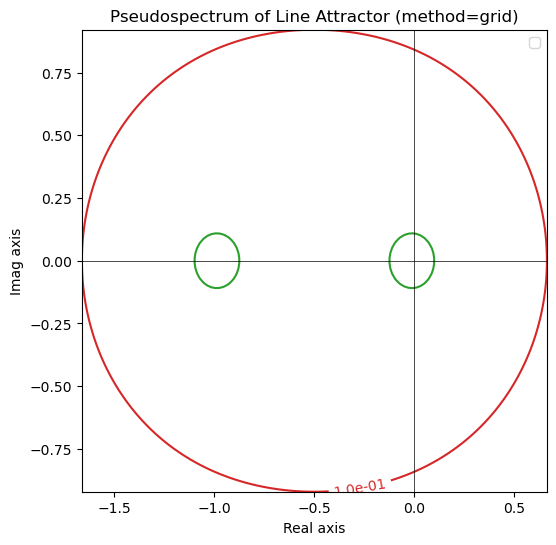

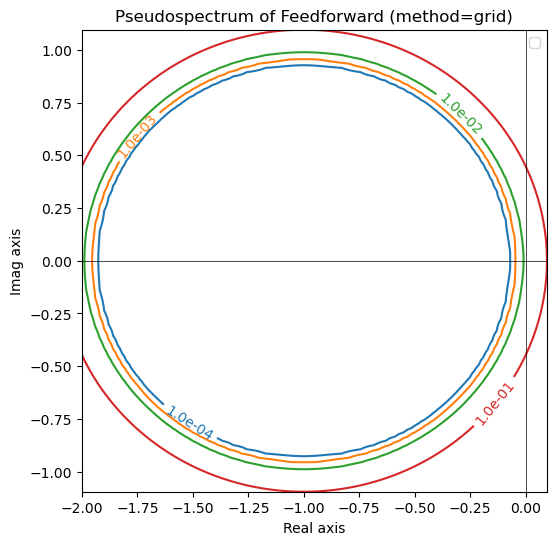

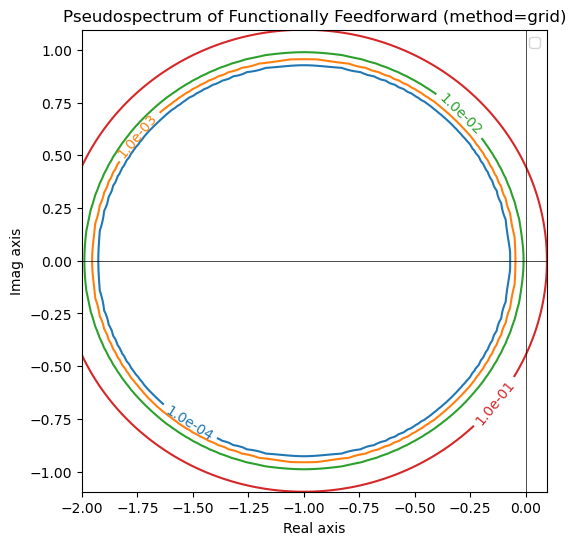

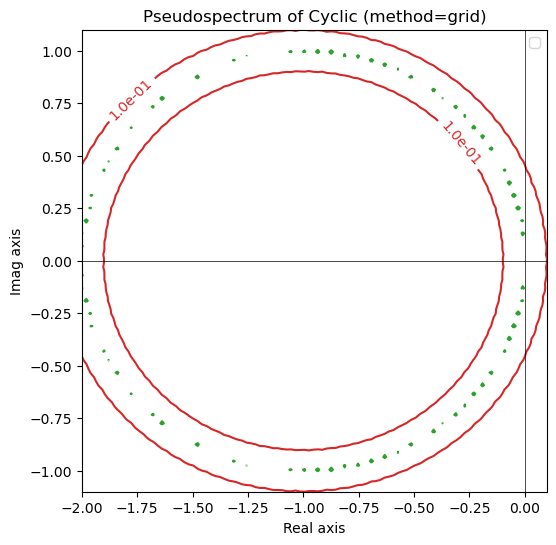

In [16]:
def create_line_attractor_network(N=100, seed=None):
    """
    Create a line attractor network of N neurons.

    Args:
        N (int): number of neurons
        seed (int): random seed for reproducibility

    Returns:
        W (np.ndarray): N x N connectivity matrix
        b (np.ndarray): vector b (eigenvector corresponding to persistent mode)
        c (np.ndarray): vector c (used to build W)
    """
    if seed is not None:
        np.random.seed(seed)

    b = np.random.randn(N)
    b = b / np.linalg.norm(b)   # normalize b

    c = np.random.randn(N)
    c = c / (np.dot(b, c))      # enforce c^T b = 1

    W = np.outer(b, c)          # rank-1 connectivity
    return W, "grid"


def create_gaussian_network():
    return 0, "auto"

def create_ffw_network(N=100):
    """ Create a feedforward network of N neurons"""
    T = np.zeros((N, N))

    for i in range(1, N):
        T[i, i - 1] = 1.0
    return T, "grid"

def create_f_ffw_network(N=100, seed=None):
    """ Create a feedforward network of N neurons"""
    if seed is not None:
        np.random.seed(seed)

    random_vectors = np.random.randn(N, N)
    U, _ = qr(random_vectors)

    T, _ = create_ffw_network(N=len(random_vectors))
    # print(U.T @ U)
    print(U.shape)
    print(T.shape)
    np.allclose(U.T @ U, np.eye(N), atol=1e-10)
    W = U @ T @ U.T
    return W, "grid"

def create_cyclic_network(N=100):
    T, _ = create_ffw_network(N=N)
    T[0, N-1] = 1.0
    return T, "grid"

def plot_pspec(W, network_title, method="auto",
                        epsilons=[1e-4, 1e-3, 1e-2, 1e-1],
                        real_range=(-2, 2),
                        imag_range=(-2, 2),
                        npts=200):
    """
    Plot pseudospectrum of connectivity matrix W with eigenvalues overlayed.

    Args:
        W (np.ndarray): network connectivity matrix (NxN).
        epsilons (list): contour levels for pseudospectrum.
        method (str): 'auto', 'grid', 'triang', or 'points'.
        real_range (tuple): (min, max) real axis range (only used if method='grid').
        imag_range (tuple): (min, max) imaginary axis range (only used if method='grid').
        npts (int): resolution of grid/mesh.

    Returns:
        fig, ax: matplotlib objects
    """
    eps_max = epsilons[-1]

    if method == "auto":
        pseudo = NonnormalMeshgridAuto(W, eps_max)
    elif method == "grid":
        pseudo = NonnormalMeshgrid(W, real_min=real_range[0], real_max=real_range[1],
                                      imag_min=imag_range[0], imag_max=imag_range[1],
                                      real_n=200, imag_n=200, method='svd')
    elif method == "triang":
        pseudo = NonnormalTriang(W, real_min=real_range[0], real_max=real_range[1],
                                    imag_min=imag_range[0], imag_max=imag_range[1])
    elif method == "points":
        # example: just evaluate a few points near eigenvalues
        eigs = np.linalg.eigvals(W)
        pts = [(ev.real, ev.imag) for ev in eigs]
        pseudo = NonnormalPoints(W, eps_max, points=pts)
    else:
        raise ValueError("method must be 'auto', 'grid', 'triang', or 'points'")

    # --- Plot ---
    fig, ax = plt.subplots(figsize=(6,6))
    cs = pseudo.plot(epsilons)

    # Overlay eigenvalues
    eigvals = np.linalg.eigvals(W)
    # ax.scatter(eigvals.real, eigvals.imag, color="red", marker="x", label="Eigenvalues")

    ax.axhline(0, color="k", linewidth=0.5)
    ax.axvline(0, color="k", linewidth=0.5)
    ax.set_xlabel("Real axis")
    ax.set_ylabel("Imag axis")
    ax.legend()
    title_full = f"Pseudospectrum of " + title + f" (method={method})"
    ax.set_title(title_full)

    return fig, ax

# doing it as W-I
eye = np.identity(100)
network_matrices = [create_line_attractor_network(), create_ffw_network(), create_f_ffw_network(), create_cyclic_network()]
network_titles = ["Line Attractor", "Feedforward", "Functionally Feedforward", "Cyclic"]

for i in range(len(network_matrices)):
    # compute pseudospectrum for the levels of interest between [1e-5, 1]
    network = network_matrices[i]
    title = network_titles[i]
    print(network[1])
    plot_pspec(network[0] - eye, title, network[1])



In [ ]:
=== Diagnostic summary ===
N = 40
eig(T) stats: min, max abs: 0.0 0.0
T nilpotent check: ||T^N|| = 0.0
||Q.T @ Q - I|| = 3.724634109354495e-15
eig(W_ortho) max abs: 0.38931548406837135

U_raw conditioning: cond(U_raw) = 27.53515379955476
eig(W_sim) max abs: 0.4274427499915596
max |eig(W_sim) - eig(T)| (sorted difference) = 0.4274427499915596
Are eig(W_sim) ~= eig(T)? False

Using GS-orthonormalized columns (U_cols_orth) -> cond = 1.0000000000000395
eig(W_cols) max abs: 0.4045867752777333
Are eig(W_cols) ~= eig(T)? False

||W_ortho - W_sim|| = 25.468440760689845
||W_ortho - T|| = 9.038464515231693

‖UᵀU - I‖ = 7.167572687036364e-15
0.6420427256276118
max |eig(T)|: 0.0
max |eig(W)|: 0.6420427256276118


AssertionError: Similarity did not preserve eigenvalues!

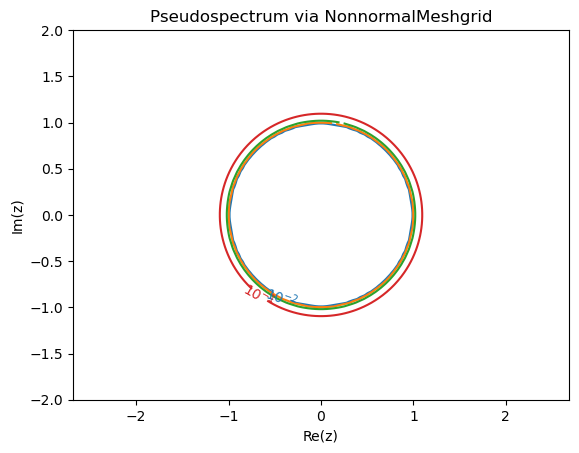

In [ ]:
# compute pseudospectrum for the levels of interest between [1e-5, 1]
# network = network_matrices[2]
# print("step 1")
# pseudo = NonnormalAuto(network, 1e-5, 1)
# print("step 2")


# Build the feedforward network
W, _ = network_matrices[1]

# Define a grid in the complex plane where we will compute pseudospectra
# Compute pseudospectrum on a grid
ps = NonnormalMeshgrid(
    W,
    real_min=-2, real_max=2,
    imag_min=-2, imag_max=2,
    real_n=100, imag_n=100,
    method='svd'
)

#ps_auto = NonnormalMeshgridAuto(W, 1)

# Plot contour lines for epsilons
epsilons = [1e-2, 10 ** (-1.8), 10 ** (-1.5), 1e-1]
ps.plot(epsilons)
plt.xlabel("Re(z)")
plt.ylabel("Im(z)")
plt.title("Pseudospectrum via NonnormalMeshgrid")
plt.axis("equal")
plt.show()

In [ ]:
import numpy as np
from numpy.linalg import eigvals, qr, inv, norm, cond, matrix_power

def create_ffw_network(N):
    T = np.zeros((N, N))
    for i in range(1, N):
        T[i, i-1] = 1.0
    return T

def diagnostics(N=100, seed=0):
    np.random.seed(seed)

    # Base T
    T = create_ffw_network(N)

    # 1) Q from QR of a random matrix (orthogonal Q)
    A = np.random.randn(N, N)
    Q, R = qr(A)   # Q is orthogonal (Q.T @ Q = I)
    W_ortho = Q @ T @ Q.T

    # 2) U as columns = random vectors (simulate Gram-Schmidt user approach)
    U_cols = np.random.randn(N, N)
    # Optionally perform Gram-Schmidt to make U_cols invertible but not orthogonal:
    # simple (unstable) GS - for demonstration only; comment out if you already have U
    def gram_schmidt_cols(X):
        X = X.copy().astype(float)
        N = X.shape[1]
        for i in range(N):
            v = X[:, i]
            for j in range(i):
                v = v - np.dot(X[:, j], v) * X[:, j]
            nrm = np.linalg.norm(v)
            if nrm < 1e-12:
                # resample if near singular
                v = np.random.randn(*v.shape)
                nrm = np.linalg.norm(v)
            X[:, i] = v / nrm
        return X
    # If you already have an orthonormal U from GS, skip this step. We'll produce U_cols_orth
    U_cols_orth = gram_schmidt_cols(U_cols)  # now columns are orthonormal (approx.)
    # But simulate the case where columns are not orthonormal: use raw U_cols:
    U_raw = np.random.randn(N, N)  # "raw" columns matrix (not orthonormal)
    # Build W using raw U (the way you might have done)
    try:
        U_inv = inv(U_raw)
        W_sim = U_raw @ T @ U_inv
    except Exception as e:
        W_sim = None
        print("Could not invert U_raw:", e)

    # Diagnostics printouts
    print("=== Diagnostic summary ===")
    print("N =", N)
    # eigenvalues of T
    eT = eigvals(T)
    print("eig(T) stats: min, max abs:", np.min(np.abs(eT)), np.max(np.abs(eT)))
    print("T nilpotent check: ||T^N|| =", norm(matrix_power(T, N)))

    # Q orthogonality
    print("||Q.T @ Q - I|| =", norm(Q.T @ Q - np.eye(N)))
    eW_ortho = eigvals(W_ortho)
    print("eig(W_ortho) max abs:", np.max(np.abs(eW_ortho)))

    # U_raw diagnostics
    print("\nU_raw conditioning: cond(U_raw) =", cond(U_raw))
    if W_sim is not None:
        eW_sim = eigvals(W_sim)
        print("eig(W_sim) max abs:", np.max(np.abs(eW_sim)))
        print("max |eig(W_sim) - eig(T)| (sorted difference) =",
              np.max(np.abs(np.sort_complex(eW_sim) - np.sort_complex(eT))))
        # show if they differ by more than tiny tol
        print("Are eig(W_sim) ~= eig(T)?", np.allclose(np.sort_complex(eW_sim),
                                                       np.sort_complex(eT), atol=1e-8))

    # Show effect of using QR Q vs raw columns:
    try:
        Ucols_inv = inv(U_cols_orth)
        W_cols = U_cols_orth @ T @ Ucols_inv
        eW_cols = eigvals(W_cols)
        print("\nUsing GS-orthonormalized columns (U_cols_orth) -> cond =", cond(U_cols_orth))
        print("eig(W_cols) max abs:", np.max(np.abs(eW_cols)))
        print("Are eig(W_cols) ~= eig(T)?", np.allclose(np.sort_complex(eW_cols),
                                                        np.sort_complex(eT), atol=1e-8))
    except Exception as e:
        print("Could not invert U_cols_orth:", e)

    # Compare matrices directly
    if W_sim is not None:
        print("\n||W_ortho - W_sim|| =", norm(W_ortho - W_sim))
        print("||W_ortho - T|| =", norm(W_ortho - T))

    return {
        'T': T, 'Q': Q, 'W_ortho': W_ortho,
        'U_raw': U_raw, 'W_sim': W_sim, 'U_cols_orth': U_cols_orth
    }

res = diagnostics(N=40, seed=1)


=== Diagnostic summary ===
N = 40
eig(T) stats: min, max abs: 0.0 0.0
T nilpotent check: ||T^N|| = 0.0
||Q.T @ Q - I|| = 3.724634109354495e-15
eig(W_ortho) max abs: 0.38931548406837135

U_raw conditioning: cond(U_raw) = 27.53515379955476
eig(W_sim) max abs: 0.4274427499915596
max |eig(W_sim) - eig(T)| (sorted difference) = 0.4274427499915596
Are eig(W_sim) ~= eig(T)? False

Using GS-orthonormalized columns (U_cols_orth) -> cond = 1.0000000000000395
eig(W_cols) max abs: 0.4045867752777333
Are eig(W_cols) ~= eig(T)? False

||W_ortho - W_sim|| = 25.468440760689845
||W_ortho - T|| = 9.038464515231693


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pseudopy.nonnormal import NonnormalMeshgrid, NonnormalMeshgridAuto

def make_line_attractor(N=100, seed=None, normalize_b=True, scale=1.0):
    """
    Create W = outer(b,c) with c chosen so that c^T b = 1.
    Optionally normalize b to unit norm (reduces nonnormality).
    scale multiplies the whole matrix W (useful to match reference gain).
    Returns W, b, c
    """
    if seed is not None:
        np.random.seed(seed)
    b = np.random.randn(N)
    if normalize_b:
        b = b / np.linalg.norm(b)
    # choose c so that b^T c = 1 exactly but without dividing by tiny dot
    c = np.random.randn(N)
    # adjust c: add correction along b so that dot becomes 1
    c = c + (1.0 - np.dot(b, c)) * b / (np.dot(b, b) + 1e-16)
    # double-check dot
    assert abs(np.dot(b, c) - 1.0) < 1e-10
    W = np.outer(b, c) * scale
    return W, b, c

def inspect_pseudo_vals(W, real_range=(-2,2), imag_range=(-2,2), n=200, method='svd'):
    """Compute pseudospectrum grid (NonnormalMeshgrid) but only return stats about sigma_min and resolvent norm."""
    ps = NonnormalMeshgrid(W, real_min=real_range[0], real_max=real_range[1],
                             imag_min=imag_range[0], imag_max=imag_range[1],
                             real_n=n, imag_n=n, method=method)
    vals = ps.Vals  # recall: this is sigma_min(A - zI)
    finite_mask = np.isfinite(vals)
    print("sigma_min: min, median, max:", np.nanmin(vals[finite_mask]), np.nanmedian(vals[finite_mask]), np.nanmax(vals[finite_mask]))
    # resolvent norm = 1 / sigma_min (guard against zero)
    with np.errstate(divide='ignore', invalid='ignore'):
        resolv = 1.0 / vals
    print("resolvent norm: min, median, max (ignoring inf):",
          np.nanmin(resolv[np.isfinite(resolv)]),
          np.nanmedian(resolv[np.isfinite(resolv)]),
          np.nanmax(resolv[np.isfinite(resolv)]))
    return ps

def plot_line_pseudospec(W, epsilons, real_range=(-2,2), imag_range=(-2,2), n=200):
    """
    Plot pseudospectra for a matrix W.

    Parameters
    ----------
    W : ndarray (N,N)
        The matrix whose pseudospectrum you want.
    epsilons : list or array
        Desired epsilon levels for contours (will be sorted ascending).
    real_range : tuple
        Range for real axis of z-plane.
    imag_range : tuple
        Range for imaginary axis of z-plane.
    n : int
        Grid resolution per axis.
    """
    # Ensure epsilons is a sorted numpy array
    epsilons = np.sort(np.array(epsilons))

    # Build grid in complex plane
    xr = np.linspace(real_range[0], real_range[1], n)
    yi = np.linspace(imag_range[0], imag_range[1], n)
    X, Y = np.meshgrid(xr, yi)
    Z = X + 1j*Y

    # Compute smallest singular value sigma_min(A - zI) at each grid point
    vals = np.zeros_like(Z.real)
    for i in range(n):
        for j in range(n):
            M = W - Z[i,j]*np.eye(W.shape[0])
            s = svd(M, compute_uv=False)
            vals[i,j] = s.min()   # sigma_min

    # Plot contours of sigma_min = eps
    fig, ax = plt.subplots(figsize=(6,5))
    cs = ax.contour(X, Y, vals, levels=epsilons, colors='k')
    ax.clabel(cs, inline=1, fontsize=8, fmt=lambda l: f"ε={l:.0e}")
    ax.set_title("Pseudospectra (sigma_min contours)")
    ax.set_xlabel("Re(z)")
    ax.set_ylabel("Im(z)")

    # Overlay eigenvalues
    eigs = np.linalg.eigvals(W)
    ax.plot(eigs.real, eigs.imag, 'ro', markersize=4, label="Eigenvalues")
    ax.legend()

    plt.show()


W, b, c = make_line_attractor(N=100, seed=0, normalize_b=True, scale=1.0)
ps = inspect_pseudo_vals(W, real_range=(-1.5,1.5), imag_range=(-1.5,1.5), n=150)



sigma_min: min, median, max: 0.0010211741677343114 0.15064491881744574 0.5670456857328663
resolvent norm: min, median, max (ignoring inf): 1.763526335109262 6.638126358398228 979.264881150205


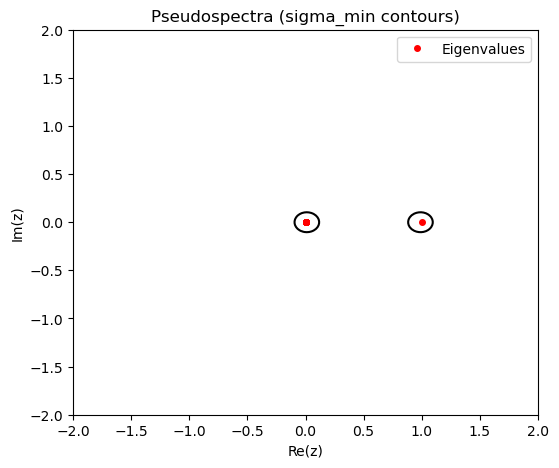

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import svd

def plot_line_pseudospec(W, epsilons, real_range=(-2,2), imag_range=(-2,2), n=200):
    """
    Plot pseudospectra for a matrix W.

    Parameters
    ----------
    W : ndarray (N,N)
        The matrix whose pseudospectrum you want.
    epsilons : list or array
        Desired epsilon levels for contours (will be sorted ascending).
    real_range : tuple
        Range for real axis of z-plane.
    imag_range : tuple
        Range for imaginary axis of z-plane.
    n : int
        Grid resolution per axis.
    """
    # Ensure epsilons is a sorted numpy array
    epsilons = np.sort(np.array(epsilons))

    # Build grid in complex plane
    xr = np.linspace(real_range[0], real_range[1], n)
    yi = np.linspace(imag_range[0], imag_range[1], n)
    X, Y = np.meshgrid(xr, yi)
    Z = X + 1j*Y

    # Compute smallest singular value sigma_min(A - zI) at each grid point
    vals = np.zeros_like(Z.real)
    for i in range(n):
        for j in range(n):
            M = W - Z[i,j]*np.eye(W.shape[0])
            s = svd(M, compute_uv=False)
            vals[i,j] = s.min()   # sigma_min

    # Plot contours of sigma_min = eps
    fig, ax = plt.subplots(figsize=(6,5))
    cs = ax.contour(X, Y, vals, levels=epsilons, colors='k')
    ax.clabel(cs, inline=1, fontsize=8, fmt=lambda l: f"ε={l:.0e}")
    ax.set_title("Pseudospectra (sigma_min contours)")
    ax.set_xlabel("Re(z)")
    ax.set_ylabel("Im(z)")

    # Overlay eigenvalues
    eigs = np.linalg.eigvals(W)
    ax.plot(eigs.real, eigs.imag, 'ro', markersize=4, label="Eigenvalues")
    ax.legend()

    plt.show()

plot_line_pseudospec(W, epsilons=[1e-4, 1e-3, 1e-2], real_range=(-2,2), imag_range=(-2,2), n=200)